In [384]:
%pylab inline

from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d
from sklearn.metrics.pairwise import cosine_similarity
from tutorial_helpers import load_model_from_ckpt, forward, slice, fnc, dr2_rgb, scatter_plot_as_images
import lightning as L
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as models
from datasets import load_dataset
from torchvision.transforms import Compose, RandomVerticalFlip, RandomHorizontalFlip, RandomRotation, RandomErasing, ToTensor, CenterCrop, ToPILImage
from fillm.run.model import *
import torch.nn.functional as F
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
import numpy as np
import warnings
import seaborn as sns
import torch.optim.lr_scheduler as lr_scheduler

sns.set()
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.5, rc={"lines.linewidth": 2})

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib
W20231204 17:06:33 3197886 py.warnings warnings.py:109] /mnt/sw/nix/store/b4q5asj8flwlgmaijgj1r6wbmnls5x8k-python-3.9.15-view/lib/python3.9/site-packages/IPython/core/magics/pylab.py:162: UserWarning: pylab import has clobbered these variables: ['indices', 'table', 'CLIP', 'dtype', 'mean', 'f', 'std', 'cm']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +



In [385]:
import math
import itertools
from functools import partial
import torch
import torch.nn.functional as F
import os
import sys
sys.path.insert(0, os.path.abspath('/mnt/home/lparker/Documents/AstroFoundationModel/AstroDino/dinov2/'))
sys.path.insert(0, os.path.abspath('/mnt/home/lparker/Documents/AstroFoundationModel/AstroDino/'))

from astrodino.data.loaders import make_data_loader
import h5py
from astropy.table import Table, join

DESI_DEFAULT_MEAN = (0.0064, 0.0123, 0.0156)
DESI_DEFAULT_STD = (0.1492, 0.2007, 0.1972)

mean = DESI_DEFAULT_MEAN
std = DESI_DEFAULT_STD

# Match morphology classifications and images

In [10]:
root='/mnt/home/flanusse/ceph/'
files = [os.path.join(root, 'images_npix152_0%02d000000_0%02d000000.h5'%(i,i+1)) for i in range(10)]

In [11]:
ra_list = []
dec_list = []
index_list = []

idx = 0
for file in files:
    with h5py.File(file, 'r') as f:
        ra = f['ra'][:]
        dec = f['dec'][:]
        
        # Append data to lists
        ra_list.extend(ra)
        dec_list.extend(dec)
        index_list.extend(range(idx, idx + len(ra)))

        idx += len(ra)

table = Table([index_list, ra_list, dec_list], names=('index', 'ra', 'dec'))

In [12]:
import gzip
import csv 
from astropy.table import Table, join

# Specify the path to your .csv.gz file
file_path = '/mnt/home/lparker/ceph/gz2_hart16.csv.gz'
 
# Open the .csv.gz file
with gzip.open(file_path, 'rb') as f:  # 'rt' mode for reading as text
    # Read the file into an astropy table
    morphologies = Table.read(f, format='ascii')

In [14]:
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.coordinates import match_coordinates_sky

table1 = table
table2 = morphologies

coords1 = SkyCoord(ra=table1['ra']*u.degree, dec=table1['dec']*u.degree)
coords2 = SkyCoord(ra=table2['ra']*u.degree, dec=table2['dec']*u.degree)

idx, d2d, d3d = coords1.match_to_catalog_sky(coords2)

d2d_arcsec = d2d.to(u.arcsec).value

# Generate logarithmically spaced bins from the smallest to the largest value
bins = np.logspace(np.log10(min(d2d_arcsec)), np.log10(max(d2d_arcsec)), 50)

# Plot the histogram with log-log scale
plt.hist(d2d_arcsec, bins=bins, log=True)
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale (redundant with log=True in plt.hist)
plt.xlabel('Separation (arcsec)')
plt.ylabel('Number of matches')
plt.title('Log-Log Histogram of d2d values')
plt.grid(True)  # Optional: Add a grid for better readability
plt.show()

max_sep = 0.5 * u.arcsec
sep_constraint = d2d < max_sep
table1_matched = table1[sep_constraint]
table2_matched = table2[idx[sep_constraint]]

indices = np.array(table1_matched['index'])
classifications = table2_matched['gz2_class']

# Get images and classifications

In [56]:
# Dataset file for DESI Legacy Survey data
from torchvision.datasets import VisionDataset
import os
from typing import Callable, List, Optional, Tuple, Union, Any
from enum import Enum
import logging
import numpy as np
import h5py
from PIL import Image as im
from torchvision import transforms

import numpy as np

"""
Transformation from raw image data (nanomaggies) to the rgb values displayed
at the legacy viewer https://www.legacysurvey.org/viewer

Code copied from
https://github.com/legacysurvey/imagine/blob/master/map/views.py
"""
def sdss_rgb(imgs, bands, scales=None,
             m = 0.02):
    import numpy as np
    rgbscales = {'u': (2,1.5), #1.0,
                 'g': (2,2.5),
                 'r': (1,1.5),
                 'i': (0,1.0),
                 'z': (0,0.4), #0.3
                 }
    if scales is not None:
        rgbscales.update(scales)

    I = 0
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        img = np.maximum(0, img * scale + m)
        I = I + img
    I /= len(bands)

    Q = 20
    fI = np.arcsinh(Q * I) / np.sqrt(Q)
    I += (I == 0.) * 1e-6
    H,W = I.shape
    rgb = np.zeros((H,W,3), np.float32)
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        rgb[:,:,plane] = (img * scale + m) * fI / I

    rgb = np.clip(rgb, 0, 1)
    return rgb

def dr2_rgb(rimgs, bands, **ignored):
    return sdss_rgb(rimgs, bands, scales=dict(g=(2,6.0), r=(1,3.4), z=(0,2.2)), m=0.03)

logger = logging.getLogger("astrodino")
_Target = float

class MaybeToTensor(transforms.ToTensor):
    """
    Convert a ``PIL Image`` or ``numpy.ndarray`` to tensor, or keep as is if already a tensor.
    """

    def __call__(self, pic):
        """
        Args:
            pic (PIL Image, numpy.ndarray or torch.tensor): Image to be converted to tensor.
        Returns:
            Tensor: Converted image.
        """
        if isinstance(pic, torch.Tensor):
            return pic
        return super().__call__(pic)

def make_normalize_transform(
    mean  = mean,
    std  = std,
) -> transforms.Normalize:
    return transforms.Normalize(mean=mean, std=std)

def make_classification_eval_transform(
    *,
    resize_size: int = 256,
    interpolation=transforms.InterpolationMode.BICUBIC,
    crop_size: int = 224,
    mean = mean,
    std = std,
) -> transforms.Compose:
    transforms_list = [
        transforms.Resize(resize_size, interpolation=interpolation),
        MaybeToTensor(),
        transforms.CenterCrop(crop_size),
        make_normalize_transform(mean=mean, std=std),
    ]
    return transforms.Compose(transforms_list)


class _Split(Enum):
    TRAIN = "train"
    VAL = "val"
    TEST = "test"  # NOTE: torchvision does not support the test split

    @property
    def length(self) -> int:
        split_lengths = {
            _Split.TRAIN: 9_500_000,
            _Split.VAL: 100_000,
            _Split.TEST: 400_000,
        }
        return split_lengths[self]


class LegacySurvey(VisionDataset):
    Target = Union[_Target]
    Split = Union[_Split]

    def __init__(
        self,
        *,
        root: str,
        indices,
        classifications,
        extra: str = None,
        transforms: Optional[Callable] = None,
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
    ) -> None:
        super().__init__(root, transforms, transform, target_transform)
        self._extra_root = extra
        self._split = split

        # We start by opening the hdf5 files located at the root directory
        self._files = [h5py.File(os.path.join(root, 'images_npix152_0%02d000000_0%02d000000.h5'%(i,i+1))) for i in range(10)]

        # Create randomized array of indices
        rng = np.random.default_rng(seed=42)
        self._indices = indices
        self._classifications = classifications
        
    @property
    def split(self) -> "LegacySurvey.Split":
        return self._split

    def __getitem__(self, index: int) -> Tuple[Any, Any]:

        true_index = self._indices[index]
        image = self._files[true_index // int(1e6)]['images'][true_index % 
                                                             int(1e6)].astype('float32')
        
        # For testing, let's convert image to PIL images
        image = im.fromarray((dr2_rgb(image, bands=['g','r','z'])*255).astype('uint8'))
        image = self.transforms(image)
        
        classification = self._classifications[index]
            
        return {'image': image, 'morph': classification}

    def __len__(self) -> int:
        return len(self._indices)

In [57]:
dataset = LegacySurvey(root='/mnt/home/flanusse/ceph/', indices=indices, classifications=classifications,  
                       transforms = make_classification_eval_transform(resize_size=152, crop_size=144))

Morphology Classification:  Ei


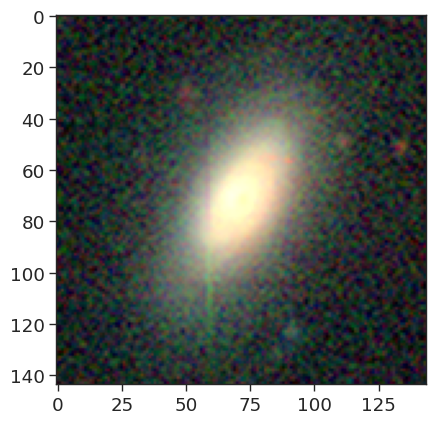

In [58]:
imshow(dataset[10000]['image'].T*torch.tensor(std) + torch.tensor(mean))
print('Morphology Classification: ', dataset[10000]['morph'])

# Load AstroCLIP

In [26]:
from dinov2.utils.config import setup
from dinov2.models import build_model_from_cfg
from dinov2.fsdp import FSDPCheckpointer
from dinov2.train.ssl_meta_arch import SSLMetaArch
from dinov2.eval.setup import setup_and_build_model
from astropy.io import fits
from dinov2.data.transforms import (
    make_normalize_transform,
)

class config:
    output_dir = '/mnt/home/lparker/ceph/dino_training'
    config_file = '/mnt/home/lparker/Documents/AstroFoundationModel/AstroDino/astrodino/configs/ssl_default_config.yaml'
    pretrained_weights = '/mnt/home/lparker/ceph/astrodino/custom/eval/training_124999/teacher_checkpoint.pth'
    opts = []
    
model, dtype = setup_and_build_model(config())

/mnt/home/lparker/Documents/AstroFoundationModel/AstroDino/dinov2/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/mnt/home/lparker/Documents/AstroFoundationModel/AstroDino/dinov2/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/mnt/home/lparker/Documents/AstroFoundationModel/AstroDino/dinov2/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


I20231204 14:04:51 3197886 dinov2 config.py:59] git:
  sha: da4b3825f0ed64b7398ace00c5062503811d0cff, status: has uncommitted changes, branch: main

I20231204 14:04:51 3197886 dinov2 config.py:60] opts: ['train.output_dir=/mnt/home/lparker/ceph/dino_training']
output_dir: /mnt/home/lparker/ceph/dino_training
I20231204 14:04:51 3197886 dinov2 config.py:26] sqrt scaling learning rate; base: 0.004, new: 0.001
I20231204 14:04:51 3197886 dinov2 config.py:33] MODEL:
  WEIGHTS: ''
compute_precision:
  grad_scaler: true
  teacher:
    backbone:
      sharding_strategy: SHARD_GRAD_OP
      mixed_precision:
        param_dtype: fp16
        reduce_dtype: fp16
        buffer_dtype: fp32
    dino_head:
      sharding_strategy: SHARD_GRAD_OP
      mixed_precision:
        param_dtype: fp16
        reduce_dtype: fp16
        buffer_dtype: fp32
    ibot_head:
      sharding_strategy: SHARD_GRAD_OP
      mixed_precision:
        param_dtype: fp16
        reduce_dtype: fp16
        buffer_dtype: fp32
 

In [27]:
def forward_im(self, x: torch.tensor):
    x = self.patch_embed(x)
    for blk in self.blocks:
            x = blk(x)
    x = self.norm(x)
    return x

class OutputExtractor(L.LightningModule):
    """
    Pass data through network to extract model outputs
    """
    def __init__(self, backbone, embed_dim=128, nhead=4, model_embed_dim=1024, dropout=0.1):    
        super().__init__()
        
        self.backbone = backbone
        self.backbone.eval()
        
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim)) 
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=nhead, batch_first=True, kdim=model_embed_dim, vdim=model_embed_dim)
        
        for param in self.backbone.parameters():
            param.requires_grad = False
            
        d_model = embed_dim
        dim_feedforward = 4*d_model
        
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.activation = nn.GELU()

    def forward(self, batch, return_weights=False):
        x, _ = batch
        batch_size = x.shape[0]
        
        with torch.no_grad():
            embedding = self.backbone(x)
                    
        attentions = self.multihead_attn(query=self.query.repeat(batch_size,1,1), key=embedding, value=embedding, need_weights=return_weights, average_attn_weights = False)
           
        x = self.norm(self.dropout1(attentions[0]))
        
        #print(x.shape)
                    
        # Small MLP head 
        x = self.dropout2(self.linear2(self.dropout1(self.activation(self.linear1(x)))))
        return x.squeeze()

# Extract encoder_q from Moco_v2 model
model.forward = forward_im.__get__(model)
model.cuda()
img_model = OutputExtractor(model)

num_params = np.sum(np.fromiter((p.numel() for p in img_model.parameters()), int))
print(f"Number of parameters in image model: {num_params:,}")

Number of parameters in image model: 303,382,016


In [28]:
# The model is saved in the Seqformer branch of Fi-LLM
model_path = "/mnt/home/sgolkar/ceph/saves/fillm/run-seqformer-2708117"
out = load_model_from_ckpt(model_path)

config = out['config']
spec_model = out['model']

In [29]:
class seq_decoder(nn.Module):

    def __init__(self,  model, embed_dim=128, nhead=4, model_embed_dim=768, dropout=0.1):
        super().__init__()

        # The query of the spectrum transformer is set to a learnable 
        self.query = nn.Parameter(torch.randn(1, 1, embed_dim)) 
        self.multihead_attn = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=nhead, batch_first=True, kdim=model_embed_dim, vdim=model_embed_dim)
        self.model = model
        
        # Freeze all of the weights of all of the intermediate layers of the pretraned Spectrum Transformer
        for param in self.model.parameters():
            param.requires_grad = False

        d_model = embed_dim
        dim_feedforward = 4 * d_model

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

        self.activation = nn.GELU()

    def forward(self, sample, return_weights=False):
        sample=sample.unsqueeze(-1)
        batch_size = len(sample)
        
        # Embed the spectrum using the pretrained model 
        with torch.no_grad():
            embedding = self.model(fnc(sample))['embedding']
                        
        # Perform single cross-attention on the embeddings
        attentions = self.multihead_attn(query=self.query.repeat(batch_size,1,1), key=embedding, value=embedding, need_weights=return_weights, average_attn_weights = False)
        x = self.norm(self.dropout1(attentions[0]))
                
        # Small MLP head 
        x = x+self.dropout2(self.linear2(self.dropout(self.activation(self.linear1(x)))))
        
        # Return weights option (for attention mask)
        if return_weights:
            return x.squeeze(), attentions[1]
        
        return x.squeeze()


# Modify the forward to output all of the embeddings
spec_model.forward = forward.__get__(spec_model, type(img_model))

# Add the decoder to the spectrum transformer
my_decoder = seq_decoder(model=spec_model)
my_decoder.cuda()

num_params = np.sum(np.fromiter((p.numel() for p in my_decoder.parameters()), int))
print(f"Number of parameters in spectrum model: {num_params:,}")

Number of parameters in spectrum model: 43,539,734


In [30]:
class CLIPLoss(nn.Module):
    def get_logits(self, image_features, spectrum_features, logit_scale):
        image_features = F.normalize(image_features, dim=-1, eps=1e-3)
        spectrum_features = F.normalize(spectrum_features, dim=-1, eps=1e-3)
        logits_per_image = logit_scale * image_features @ spectrum_features.T
        return logits_per_image, logits_per_image.T

    def forward(self, image_features, spectrum_features, logit_scale, output_dict=False):
        logits_per_image, logits_per_spectrum = self.get_logits(image_features, spectrum_features, logit_scale)
        labels = torch.arange(logits_per_image.shape[0], device=image_features.device, dtype=torch.long)
        total_loss = (
            F.cross_entropy(logits_per_image, labels) +
            F.cross_entropy(logits_per_spectrum, labels)
        ) / 2
        return {"contrastive_loss": total_loss} if output_dict else total_loss

In [31]:
# Define image and spectrum encoders
image_encoder = img_model
spectrum_encoder = seq_decoder(model=spec_model)   

num_params_im = sum(p.numel() for p in image_encoder.parameters())
num_params_sp = sum(p.numel() for p in my_decoder.parameters())
print(f"Image Encoder Params: {round(num_params_im/1e6, 1)} M, Spectrum Encoder Params: {round(num_params_sp/1e6, 1)} M")

W20231204 14:05:07 3197886 py.warnings warnings.py:109] /tmp/ipykernel_3197886/3324592073.py:5: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  num_params_im = sum(p.numel() for p in image_encoder.parameters())

W20231204 14:05:07 3197886 py.warnings warnings.py:109] /tmp/ipykernel_3197886/3324592073.py:6: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  num_params_sp = sum(p.numel() for p in my_decoder.parameters())

Image Encoder Params: 303.4 M, Spectrum Encoder Params: 43.5 M


In [394]:
class AstroCLIP(L.LightningModule):
    def __init__(self, image_encoder, spectrum_encoder):
        super().__init__()
        self.image_encoder = image_encoder
        
        # Freeze all but the last layers of the image encoder
        #for name, child in self.image_encoder.backbone.named_children():
        #   if name != 'fc':
        #        for param in child.parameters():
        #            param.requires_grad = False

        # Spectrum encoder is already frozen, so simply load it in
        self.spectrum_encoder = spectrum_encoder
        
        # Logit scale is fixed to 15.5 and is not a learnable parameter
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(15.5))
        #self.logit_scale = np.log(15.5)
        self.criterion = CLIPLoss()
        
    def forward(self, x, image=True, return_weights=False):
        if image:
            # Embed image
            embedding = self.image_encoder((x,None))
        else:
            # Embed spectrum
            embedding = self.spectrum_encoder(x, return_weights=return_weights)
        return embedding


    def training_step(self, batch, batch_idx):
        # Training_step defines the train loop. It is independent of forward
        im, sp = batch['image'], batch['spectrum'].squeeze()
        im = image_transforms(im).to('cuda')
        image_features = self.image_encoder((im, None))
        spectrum_features = self.spectrum_encoder(sp)
        loss_withlogit = self.criterion(image_features, spectrum_features, 15.5)
        self.log("train_loss_withlogit", loss_withlogit)
        loss_nologit = self.criterion(image_features, spectrum_features, 1)
        self.log("train_loss_nologit", loss_nologit)
        self.log("scale", self.logit_scale)
        return loss_withlogit

    def validation_step(self, batch, batch_idx):
        # Validation_step defines the validation loop. It is independent of forward
        im, sp = batch['image'], batch['spectrum'].squeeze()
        im = image_transforms(im).to('cuda')
        image_features = self.image_encoder((im, None))
        spectrum_features = self.spectrum_encoder(sp)
        val_loss_nologit = self.criterion(image_features, spectrum_features, 1)
        self.log("val_loss_nologit", val_loss_nologit)
        val_loss_withlogit = self.criterion(image_features, spectrum_features, 15.5)
        self.log("val_loss_withlogit", val_loss_withlogit)
    
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-5, weight_decay=0.2)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=80, eta_min=5e-6)
        return {
        'optimizer': optimizer,
        'lr_scheduler': {
            'scheduler': scheduler,
            'interval': 'epoch',  # or 'step' for step-wise updating
            'frequency': 1,  # how often to apply
        }
    }

CLIP = AstroCLIP(image_encoder, spectrum_encoder)

In [395]:
ckpt = torch.load('./astroclip-clip-align/lghz7i8w/checkpoints/epoch=239-step=74400.ckpt')

In [396]:
CLIP.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

# Embed

In [60]:
from tqdm import tqdm

embeddings = []
morphologies = []
images = []

CLIP.eval()
CLIP.cuda()

with torch.no_grad():
    for i in tqdm(range(len(dataset)//1024)):
        img = torch.stack([dataset[j +i*1024]['image'] for j in range(1024)],  dim=0)
        morph = np.stack([dataset[j +i*1024]['morph'] for j in range(1024)])
        
        images.append(img * np.array(std)[:, np.newaxis, np.newaxis] + np.array(mean)[:, np.newaxis, np.newaxis])
        embeddings.append(CLIP(img.cuda()).detach().cpu())
        morphologies.append(morph)

        del img
        
embeddings = np.concatenate(embeddings)
morphologies = np.concatenate(morphologies)

100%|██████████| 81/81 [11:02<00:00,  8.17s/it]


# Filter down Classifications

In [237]:
import pandas as pd
reduced_morphs = np.array([s[:1] for s in morphologies])
np.unique(reduced_morphs)

array(['A', 'E', 'S'], dtype='<U1')

# Train on Images

In [239]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = torch.tensor(embeddings, dtype=torch.float32)
y = torch.tensor(le.fit_transform(reduced_morphs), dtype=torch.int64)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True)

from torch.utils.data import WeightedRandomSampler

class_counts = torch.bincount(y_train)
class_weights = 1. / class_counts.float()
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=1024, sampler=sampler)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=1024)

In [240]:
class_mapping = {index: label for index, label in enumerate(le.classes_)}

## KNN

In [241]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=16)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_val)

In [242]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_val, y_pred)
accuracies = cm.diagonal() / cm.sum(axis=1)
class_labels = np.unique(y_val)  # Assuming y_val contains all class labels

# Print accuracy for each class
for class_label, accuracy in zip(class_labels, accuracies):
    print(f'Accuracy for class {class_mapping[class_label]}: {100*accuracy:.2f}%')

Accuracy for class A: 0.00%
Accuracy for class E: 71.88%
Accuracy for class S: 74.14%


## MLP

In [243]:
from torch import nn

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout=0.1):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lrelu1 = nn.LeakyReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.lrelu2 = nn.LeakyReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.dropout1(out)
        out = self.lrelu1(out)
        out = self.fc2(out)
        out = self.dropout2(out)
        out = self.lrelu2(out)
        out = self.fc3(out)
        return out

# Example model instantiation
model = MLP(input_size=X.shape[1], hidden_size=512, num_classes=len(set(reduced_morphs))).cuda()

In [244]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

# Training loop
num_epochs = 200
for epoch in tqdm(range(num_epochs)):
    epoch_loss = 0
    for inputs, labels in train_loader:
        outputs = model(inputs.cuda())
        loss = criterion(outputs, labels.cuda())

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    
    epoch_loss = 0
    for inputs, labels in val_loader:
        outputs = model(inputs.cuda())
        loss = criterion(outputs, labels.cuda())    
        epoch_loss += loss.item()
    epoch_loss /= len(val_loader)
    val_losses.append(epoch_loss)

100%|██████████| 200/200 [02:11<00:00,  1.52it/s]


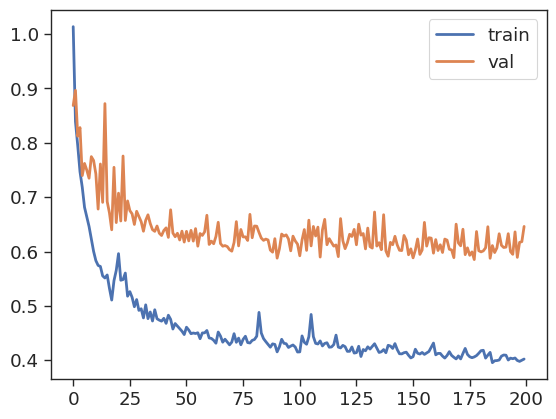

In [245]:
plot(train_losses, label='train')
plot(val_losses, label='val')
legend()

In [246]:
from collections import defaultdict

model.eval()  # Set the model to evaluation mode

# Initialize dictionaries to store correct predictions and total count per class
correct_pred = defaultdict(int)
total_pred = defaultdict(int)

with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.cuda()).detach().cpu()
        _, predicted = torch.max(outputs, 1)

        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_pred[label.item()] += 1
            total_pred[label.item()] += 1

total_correct = 0
total_total_pred = 0
            
# Calculate and print accuracy for each class
for class_id in total_pred.keys():
    accuracy = 100 * correct_pred[class_id] / total_pred[class_id]
    print(f'Class {class_mapping[class_id]}: Accuracy = {accuracy:.2f}%')
    
    total_correct += correct_pred[class_id]
    total_total_pred += total_pred[class_id]
    
total_acc = 100*total_correct/total_total_pred
print(f'Total accuracy: {total_acc:.2f}%')

Class S: Accuracy = 69.11%
Class E: Accuracy = 76.40%
Class A: Accuracy = 15.00%
Total accuracy: 72.08%


# On .... SPECTRA?

In [272]:
import h5py
from astropy.table import Table, join
import numpy as np
import pandas as pd
from tqdm import tqdm

DATA_DIR='/mnt/home/flanusse/ceph'

# Open matched catalog
joint_cat = pd.read_parquet(DATA_DIR+'/matched_catalog.pq').drop_duplicates(subset=["key"])

In [277]:
import gzip
import csv 
from astropy.table import Table, join

# Specify the path to your .csv.gz file
file_path = '/mnt/home/lparker/ceph/gz2_hart16.csv.gz'
 
# Open the .csv.gz file
with gzip.open(file_path, 'rb') as f:  # 'rt' mode for reading as text
    # Read the file into an astropy table
    morphologies = Table.read(f, format='ascii')

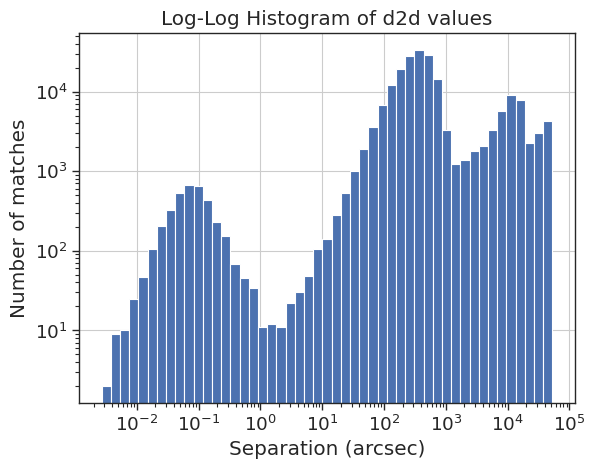

In [301]:
table1 = joint_cat[['targetid', 'ra', 'dec']]
table2 = morphologies[['ra', 'dec', 'gz2_class']]

coords1 = SkyCoord(ra=table1['ra']*u.degree, dec=table1['dec']*u.degree)
coords2 = SkyCoord(ra=table2['ra']*u.degree, dec=table2['dec']*u.degree)

idx, d2d, d3d = coords1.match_to_catalog_sky(coords2)

d2d_arcsec = d2d.to(u.arcsec).value

# Generate logarithmically spaced bins from the smallest to the largest value
bins = np.logspace(np.log10(min(d2d_arcsec)), np.log10(max(d2d_arcsec)), 50)

# Plot the histogram with log-log scale
plt.hist(d2d_arcsec, bins=bins, log=True)
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.yscale('log')  # Set y-axis to logarithmic scale (redundant with log=True in plt.hist)
plt.xlabel('Separation (arcsec)')
plt.ylabel('Number of matches')
plt.title('Log-Log Histogram of d2d values')
plt.grid(True)  # Optional: Add a grid for better readability
plt.show()

max_sep = 0.5 * u.arcsec
sep_constraint = d2d < max_sep
table1_matched = table1[sep_constraint]
table2_matched = table2[idx[sep_constraint]]

tids = np.array(table1_matched['targetid'])
classifications = table2_matched['gz2_class']

In [426]:
dataset = load_dataset('../../astroclip/datasets/legacy_survey.py', cache_dir=CACHE_DIR)
dataset.set_format(type='torch', columns=['spectrum', 'targetid'])
val_dataloader = torch.utils.data.DataLoader(dataset['test'], batch_size=512, shuffle=False, num_workers=10)

In [352]:
spectra = []
targetids = []

for data in tqdm(dataset['train']):
    spectra.append(data['spectrum'])
    targetids.append(data['targetid'])
    
for data in tqdm(dataset['test']):
    spectra.append(data['spectrum'])
    targetids.append(data['targetid'])

100%|██████████| 39599/39599 [00:13<00:00, 2850.76it/s]


In [359]:
spectra = torch.concatenate(spectra, axis=1).T
targetids = torch.tensor(targetids)

In [374]:
spectra_morph = []
class_morph = []

tidx = 0
for tid in tqdm(tids):
    if tid in targetids:
        idx = np.where(targetids == tid)[0]
        spectra_morph.append(spectra[idx])
        class_morph.append(classifications[tidx])
        
    tidx += 1

100%|██████████| 3482/3482 [00:00<00:00, 5844.73it/s]


In [381]:
spectra_morph = torch.stack(spectra_morph, dim=0)
class_morph = torch.tensor(class_morph)

TypeError: concatenate(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

In [433]:
spectra_embed = []
for spec in tqdm(spectra_morph):
    with torch.no_grad():
        sp = spec[None, :].cuda()
        spectra_embed.append(CLIP(sp.cuda(), False).detach().cpu())

100%|██████████| 3482/3482 [00:30<00:00, 113.68it/s]


In [446]:
spectra_embed = torch.stack(spectra_embed, dim=0)

In [466]:
X_spec = spectra_embed
y_spec = torch.tensor(le.transform(class_morph))

spec_loader = DataLoader(TensorDataset(X_spec, y_spec), batch_size=1024)

In [467]:
from collections import defaultdict

model.eval()  # Set the model to evaluation mode

# Initialize dictionaries to store correct predictions and total count per class
correct_pred = defaultdict(int)
total_pred = defaultdict(int)

with torch.no_grad():
    for inputs, labels in spec_loader:
        outputs = model(inputs.cuda()).detach().cpu()
        _, predicted = torch.max(outputs, 1)

        for label, prediction in zip(labels, predicted):
            if label == prediction:
                correct_pred[label.item()] += 1
            total_pred[label.item()] += 1

total_correct = 0
total_total_pred = 0
            
# Calculate and print accuracy for each class
for class_id in total_pred.keys():
    accuracy = 100 * correct_pred[class_id] / total_pred[class_id]
    print(f'Class {class_mapping[class_id]}: Accuracy = {accuracy:.2f}%')
    
    total_correct += correct_pred[class_id]
    total_total_pred += total_pred[class_id]
    
total_acc = 100*total_correct/total_total_pred
print(f'Total accuracy: {total_acc:.2f}%')

Class E: Accuracy = 86.97%
Class S: Accuracy = 21.78%
Total accuracy: 48.79%
